In [2]:
import warnings
import numpy as np
from tqdm import tqdm

# Para evitar warning de divisão por zero
warnings.simplefilter(action='ignore')

def NLM(img, h, f, t):

    
    # Dimenssões espaciais da imagem
    m, n = img.shape

    # Cria imagem de saída
    filtrada = np.zeros((m, n))

    # Problema de valor de contorno: replicar bordas
    #img_n = np.pad(ruidosa, ((f, f), (f, f)), 'symmetric') # Modifiquei esta linha
    img_n = np.pad(img, ((f, f), (f, f)), 'symmetric')


    # Initializing the counter
    prog = tqdm(total=m*n, position=0, leave=True)

    # Loop principal do NLM
    for i in range(m):
        for j in range(n):

            im = i + f;   # compensar a borda adicionada artificialmente
            jn = j + f;   # compensar a borda adicionada artificialmente

            # Obtém o patch ao redor do pixel corrente
            W1 = img_n[im-f:(im+f)+1, jn-f:(jn+f)+1]

            # Calcula as bordas da janela de busca para o pixel corrente (se pixel próximo das bordas, janela de busca é menor)
            rmin = max(im-t, f);  # linha inicial
            rmax = min(im+t, m+f);  # linha final
            smin = max(jn-t, f);  # coluna inicial
            smax = min(jn+t, n+f);  # coluna final

            # Calcula média ponderada
            NL = 0      # valor do pixel corrente filtrado
            Z = 0       # constante normalizadora

            # Loop para todos os pixels da janela de busca
            for r in range(rmin, rmax):
                for s in range(smin, smax):

                    # Obtém o patch ao redor do pixel a ser comparado
                    W2 = img_n[r-f:(r+f)+1, s-f:(s+f)+1]

                    # Calcula o quadrado da distância Euclidiana
                    d2 = np.sum((W1 - W2)*(W1 - W2))

                    # Calcula a medida de similaridade
                    sij = np.exp(-d2/(h**2))

                    # Atualiza Z e NL
                    Z = Z + sij
                    NL = NL + sij*img_n[r, s]

            # Normalização do pixel filtrado
            filtrada[i, j] = NL/Z
            prog.update(1)
    return filtrada

In [ ]:
import cv2
img = cv2.imread("images/Lenna_ruidosa.png", cv2.IMREAD_GRAYSCALE)

filtrada = NLM(img,1,3,10)

### NLM versão ChatGpt

In [ ]:
import cv2
import numpy as np

def non_local_means_denoising(image, h=10, patch_size=5, search_size=17):
    """
    Implementação do Non-Local Means (NLM) para remoção de ruído.
    :param image: Imagem de entrada (numpy array, escala de cinza).
    :param h: Fator de filtragem (maior valor remove mais ruído, mas pode borrar a imagem).
    :param patch_size: Tamanho do patch (área considerada para similaridade local).
    :param search_size: Tamanho da área de busca ao redor de cada pixel.
    :return: Imagem filtrada.
    """
    
    # Converte para float para evitar problemas de precisão
    image = image.astype(np.float32)
    
    # Dimensões da imagem
    rows, cols = image.shape
    
    # Define metade dos tamanhos
    half_patch = patch_size // 2
    half_search = search_size // 2
    
    # Resultado final
    filtered_image = np.zeros_like(image)
    
    # Pad para lidar com bordas
    padded_image = cv2.copyMakeBorder(image, half_search, half_search, half_search, half_search, cv2.BORDER_REFLECT)
    
    for i in range(rows):
        for j in range(cols):
            i_p = i + half_search
            j_p = j + half_search
            
            # Extrai o patch central
            patch_center = padded_image[i_p - half_patch:i_p + half_patch + 1, j_p - half_patch:j_p + half_patch + 1]
            
            weights = []
            values = []
            
            # Percorre a janela de busca
            for m in range(-half_search, half_search + 1):
                for n in range(-half_search, half_search + 1):
                    
                    if m == 0 and n == 0:
                        continue
                    
                    # Extrai o patch vizinho
                    patch_neighbor = padded_image[i_p + m - half_patch:i_p + m + half_patch + 1, j_p + n - half_patch:j_p + n + half_patch + 1]
                    
                    # Calcula a distância Euclidiana entre os patches
                    dist = np.sum((patch_center - patch_neighbor) ** 2)
                    weight = np.exp(-dist / (h ** 2))
                    
                    weights.append(weight)
                    values.append(padded_image[i_p + m, j_p + n])
            
            # Normaliza os pesos
            weights = np.array(weights)
            weights /= np.sum(weights)
            
            # Aplica os pesos aos valores e atribui ao pixel filtrado
            filtered_image[i, j] = np.sum(weights * np.array(values))
    
    return np.clip(filtered_image, 0, 255).astype(np.uint8)

# Exemplo de uso
if __name__ == "__main__":
    img = cv2.imread("ruidosa/ruidosa_salt_pepper.png", cv2.IMREAD_GRAYSCALE)
    denoised_img = non_local_means_denoising(img, h=10, patch_size=3, search_size=17)
    cv2.imwrite("imagem_denoised.jpg", denoised_img)
    cv2.imshow("Denoised Image", denoised_img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


In [ ]:
from skimage import img_as_float
from skimage.util import random_noise
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

def non_local_means(image, patch_size=5, search_size=17, h=10):
    """
    Aplica o algoritmo Non-Local Means para remoção de ruído.
    - image: imagem de entrada (numpy array).
    - patch_size: tamanho do patch local (pequena vizinhança).
    - search_size: tamanho da área de busca para encontrar pixels semelhantes.
    - h: parâmetro de suavização (quanto maior, mais agressivo o filtro).
    """
    image = img_as_float(image)  # Normalizar para [0,1]
    filtered_image = np.zeros_like(image)
    pad_size = search_size // 2  # Padding para bordas
    padded_image = np.pad(image, pad_size, mode='reflect')

    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            i_p = i + pad_size
            j_p = j + pad_size
            
            patch = padded_image[i_p - patch_size//2 : i_p + patch_size//2 + 1, 
                                 j_p - patch_size//2 : j_p + patch_size//2 + 1]
            
            # Janela de busca
            search_window = padded_image[i_p - pad_size : i_p + pad_size + 1, 
                                         j_p - pad_size : j_p + pad_size + 1]

            # Computar pesos
            weights = np.zeros_like(search_window)
            for m in range(search_window.shape[0] - patch_size + 1):
                for n in range(search_window.shape[1] - patch_size + 1):
                    neighbor_patch = search_window[m:m+patch_size, n:n+patch_size]
                    distance = np.sum((patch - neighbor_patch) ** 2)
                    weights[m, n] = np.exp(-distance / (h ** 2))

            # Normalizar pesos e calcular pixel filtrado
            weights /= np.sum(weights)
            filtered_pixel = np.sum(weights * search_window)
            filtered_image[i, j] = filtered_pixel

    return filtered_image

# Criar imagem com ruído para teste
image = np.zeros((256, 256))
image[25:75, 25:75] = 1  # Quadrado branco
noisy_image = random_noise(image, var=0.02)  # Adicionar ruído

# Aplicar filtro
filtered_image = non_local_means(noisy_image)

# Exibir imagens
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(noisy_image, cmap="gray")
axs[0].set_title("Imagem com Ruído")
axs[0].axis("off")

axs[1].imshow(filtered_image, cmap="gray")
axs[1].set_title("Imagem Filtrada (NLM)")
axs[1].axis("off")

plt.show()


C:\Users\adria\AppData\Local\Temp\ipykernel_5156\1426259259.py:27: RuntimeWarning: overflow encountered in scalar subtract
  weight = abs(patch[i, j] - patch[i, j+1])
C:\Users\adria\AppData\Local\Temp\ipykernel_5156\1426259259.py:24: RuntimeWarning: overflow encountered in scalar subtract
  weight = abs(patch[i, j] - patch[i+1, j])


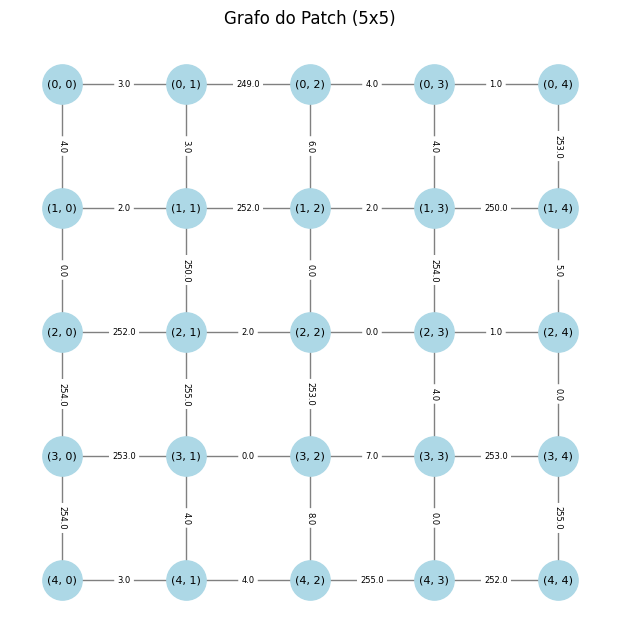

In [14]:
import numpy as np
import cv2
import networkx as nx
import matplotlib.pyplot as plt

def extract_patch(image, center, size=5):
    """Extrai um patch quadrado da imagem, centralizado em `center` com tamanho `size`."""
    x, y = center
    half = size // 2
    return image[x - half:x + half + 1, y - half:y + half + 1]

def build_patch_graph(patch):
    """Cria um grafo onde os nós são pixels e as arestas têm pesos baseados na diferença de intensidade."""
    rows, cols = patch.shape
    G = nx.Graph()

    for i in range(rows):
        for j in range(cols):
            G.add_node((i, j), intensity=patch[i, j])

    for i in range(rows):
        for j in range(cols):
            if i + 1 < rows:
                weight = abs(patch[i, j] - patch[i+1, j])
                G.add_edge((i, j), (i+1, j), weight=weight)
            if j + 1 < cols:
                weight = abs(patch[i, j] - patch[i, j+1])
                G.add_edge((i, j), (i, j+1), weight=weight)

    return G

def plot_graph(G, patch_size):
    """Plota o grafo com os pixels do patch."""
    pos = {node: (node[1], -node[0]) for node in G.nodes()}  # Ajuste da posição no grid
    labels = {node: G.nodes[node]['intensity'] for node in G.nodes()}
    edge_labels = {(u, v): f"{G[u][v]['weight']:.1f}" for u, v in G.edges()}

    plt.figure(figsize=(6, 6))
    nx.draw(G, pos, with_labels=True, node_size=800, node_color="lightblue", font_size=8, edge_color="gray")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, label_pos=0.5)
    plt.title(f"Grafo do Patch ({patch_size}x{patch_size})")
    plt.show()

# Carregar imagem em escala de cinza
image = cv2.imread("ruidosa/ruidosa_salt_pepper.png", cv2.IMREAD_GRAYSCALE)

# Selecionar um patch centralizado em (100, 100)
center = (100, 100)
patch_size = 5
patch = extract_patch(image, center, patch_size)

# Criar o grafo do patch
G = build_patch_graph(patch)

# Visualizar o grafo
plot_graph(G, patch_size)


In [ ]:
import numpy as np
import cv2
import networkx as nx
import matplotlib.pyplot as plt

# === 1. Construção do Grafo ===
def build_image_graph(image):
    """Cria um grafo com conectividade 8, onde pixels são nós e arestas têm pesos baseados na diferença de intensidade."""
    rows, cols = image.shape
    G = nx.Graph()

    # Adicionar nós (pixels) ao grafo
    for i in range(rows):
        for j in range(cols):
            G.add_node((i, j), intensity=image[i, j])

    # Adicionar arestas (conectividade 8)
    directions = [
        (0, 1), (1, 0), (0, -1), (-1, 0),  # Horizontais e Verticais
        (1, 1), (1, -1), (-1, 1), (-1, -1)  # Diagonais
    ]

    for i in range(rows):
        for j in range(cols):
            for di, dj in directions:
                ni, nj = i + di, j + dj
                if 0 <= ni < rows and 0 <= nj < cols:
                    weight = abs(image[i, j] - image[ni, nj]) + 1
                    if di != 0 and dj != 0:  # Ajuste para diagonais
                        weight *= np.sqrt(2)
                    G.add_edge((i, j), (ni, nj), weight=weight)

    return G

# === 2. Visualização do Grafo para um Pixel Central ===
def plot_graph(G, center, patch_size):
    """Exibe o grafo de um pixel central e sua janela de similaridade."""
    patch = extract_patch(center, patch_size)
    subgraph = G.subgraph(patch)

    pos = {node: (node[1], -node[0]) for node in subgraph.nodes()}  # Ajustar posição
    plt.figure(figsize=(6, 6))
    nx.draw(subgraph, pos, with_labels=True, node_size=300, node_color="lightblue", edge_color="gray")
    plt.title(f"Grafo do Pixel {center} e sua Janela de Similaridade ({patch_size}x{patch_size})")
    plt.show()

# === 3. Cálculo da Distância Geodésica ===
def geodesic_distance(G, patch1, patch2):
    """Calcula a distância geodésica média entre dois patches no grafo."""
    distances = []
    for p1 in patch1:
        for p2 in patch2:
            try:
                dist = nx.shortest_path_length(G, source=p1, target=p2, weight="weight")
                distances.append(dist)
            except nx.NetworkXNoPath:
                distances.append(np.inf)  # Caso não haja caminho
    return np.mean(distances)

# === 4. Extração de Patches ===
def extract_patch(center, size):
    """Extrai um patch ao redor de um pixel central."""
    x, y = center
    half = size // 2
    return [(i, j) for i in range(x-half, x+half+1) for j in range(y-half, y+half+1)]

# === 5. Aplicação do Filtro NLM com Distância Geodésica ===
def nlm_geodesic_denoise(image, G, patch_size=5, search_size=21, h=10):
    """Aplica Non-Local Means usando distância geodésica no grafo."""
    rows, cols = image.shape
    output = np.zeros_like(image, dtype=np.float32)

    for i in range(rows):
        for j in range(cols):
            patch1 = extract_patch((i, j), patch_size)
            i_min, i_max = max(i-search_size//2, 0), min(i+search_size//2, rows)
            j_min, j_max = max(j-search_size//2, 0), min(j+search_size//2, cols)

            weights = []
            pixels = []
            
            for x in range(i_min, i_max):
                for y in range(j_min, j_max):
                    patch2 = extract_patch((x, y), patch_size)
                    dist = geodesic_distance(G, patch1, patch2)
                    weight = np.exp(-dist**2 / (h**2))
                    weights.append(weight)
                    pixels.append(image[x, y])

            weights = np.array(weights)
            pixels = np.array(pixels)
            output[i, j] = np.sum(weights * pixels) / np.sum(weights)

    return np.uint8(output)

# === 6. Teste com uma Imagem ===
# Carregar imagem em escala de cinza
image = cv2.imread("ruidosa/ruidosa_salt_pepper.png", cv2.IMREAD_GRAYSCALE)

# Construir grafo
G = build_image_graph(image)
print(f"Grafo criado com {len(G.nodes())} nós e {len(G.edges())} arestas.")

# Escolher um pixel central para visualizar o grafo
pixel_central = (100, 100)  # Ajuste conforme a imagem
plot_graph(G, pixel_central, patch_size=5)

# Aplicar o filtro
denoised_image = nlm_geodesic_denoise(image, G)
cv2.imwrite("denoised.png", denoised_image)

# Mostrar imagem original e filtrada
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Imagem Original")
plt.subplot(1, 2, 2)
plt.imshow(denoised_image, cmap="gray")
plt.title("Imagem Filtrada (Geodesic NLM)")
plt.show()


In [ ]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, window_size=21):
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(H):
        for j in range(W):
            G.add_node((i, j), intensity=image[i, j])
            
            for di, dj in [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < H and 0 <= nj < W:
                    weight = np.abs(int(image[i, j]) - int(image[ni, nj]))
                    G.add_edge((i, j), (ni, nj), weight=weight + 1e-5)
    return G

def compute_geodesic_distance(G, center, patch_size):
    half = patch_size // 2
    distances = {}
    for node in G.nodes():
        if abs(node[0] - center[0]) <= half and abs(node[1] - center[1]) <= half:
            try:
                distances[node] = nx.shortest_path_length(G, source=center, target=node, weight='weight')
            except nx.NetworkXNoPath:
                distances[node] = np.inf
    return distances

def apply_nlm_geodesic(image, G, patch_size=21, h=10):
    H, W = image.shape
    output = np.zeros_like(image, dtype=np.float32)
    
    for i in range(H):
        for j in range(W):
            distances = compute_geodesic_distance(G, (i, j), patch_size)
            weights = np.exp(-np.array(list(distances.values())) / (h**2))
            
            total_weight = np.sum(weights)
            if total_weight > 0:
                output[i, j] = np.sum(weights * np.array([image[n] for n in distances.keys()])) / total_weight
            else:
                output[i, j] = image[i, j]
    
    return output.astype(np.uint8)

def visualize_graph(image, G, center, patch_size):
    half = patch_size // 2
    roi = image[center[0] - half:center[0] + half + 1, center[1] - half:center[1] + half + 1]
    
    pos = {node: (node[1], node[0]) for node in G.nodes() if abs(node[0] - center[0]) <= half and abs(node[1] - center[1]) <= half}
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(roi, cmap='gray')
    nx.draw(G, pos, node_size=30, edge_color='gray', alpha=0.3, with_labels=False)
    nx.draw_networkx_nodes(G, pos, nodelist=[center], node_color='red', node_size=100)
    plt.title(f"Grafo e Caminhos para o Pixel Central {center}")
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Construir o grafo
graph = build_graph(image)

# Aplicar filtragem usando distância geodésica
filtered_image = apply_nlm_geodesic(image, graph)

# Visualizar grafo e caminhos
pixel_central = (100, 100)
visualize_graph(image, graph, pixel_central, patch_size=21)

# Mostrar imagens
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Imagem com Ruído")
ax[1].imshow(filtered_image, cmap='gray')
ax[1].set_title("Imagem Filtrada (Geodésico NLM)")
plt.show()


In [ ]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21):
    half = patch_size // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            for di, dj in [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]:
                ni, nj = i + di, j + dj
                if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                    weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                    G.add_edge((i, j), (ni, nj), weight=weight)
    return G

def compute_geodesic_distance(G, center):
    return nx.single_source_dijkstra_path_length(G, source=center, weight='weight')

def apply_nlm_geodesic(image, patch_size=21, h=10):
    H, W = image.shape
    output = np.zeros_like(image, dtype=np.float32)
    
    for i in range(H):
        for j in range(W):
            G = build_graph(image, (i, j), patch_size)
            distances = compute_geodesic_distance(G, (i, j))
            
            weights = np.exp(-np.array(list(distances.values())) / (h**2))
            total_weight = np.sum(weights)
            
            if total_weight > 0:
                output[i, j] = np.sum(weights * np.array([image[n] for n in distances.keys()])) / total_weight
            else:
                output[i, j] = image[i, j]
    
    return output.astype(np.uint8)

def visualize_graph(image, center, patch_size):
    G = build_graph(image, center, patch_size)
    pos = {node: (node[1], node[0]) for node in G.nodes()}
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image, cmap='gray')
    nx.draw(G, pos, node_size=30, edge_color='gray', alpha=0.3, with_labels=False)
    nx.draw_networkx_nodes(G, pos, nodelist=[center], node_color='red', node_size=100)
    plt.title(f"Grafo e Caminhos para o Pixel Central {center}")
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Aplicar filtragem usando distância geodésica
filtered_image = apply_nlm_geodesic(image)

# Visualizar grafo e caminhos
pixel_central = (100, 100)
visualize_graph(image, pixel_central, patch_size=21)

# Mostrar imagens
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Imagem com Ruído")
ax[1].imshow(filtered_image, cmap='gray')
ax[1].set_title("Imagem Filtrada (Geodésico NLM)")
plt.show()

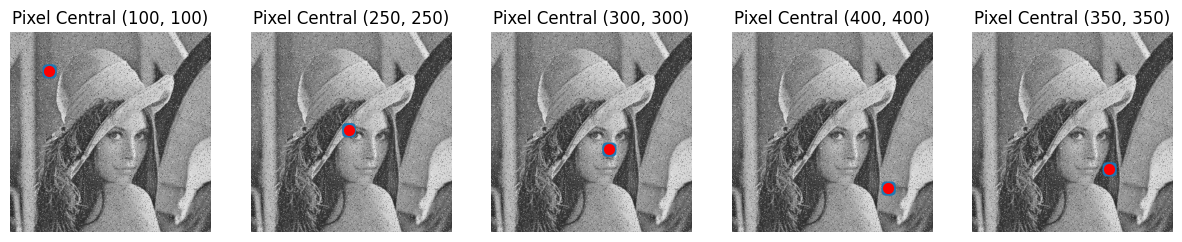

In [5]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21):
    half = patch_size // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            for di, dj in [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]:
                ni, nj = i + di, j + dj
                if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                    weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                    G.add_edge((i, j), (ni, nj), weight=weight)
    return G

def visualize_graph(image, centers, patch_size):
    fig, axes = plt.subplots(1, len(centers), figsize=(15, 5))
    
    for ax, center in zip(axes, centers):
        G = build_graph(image, center, patch_size)
        pos = {node: (node[1], node[0]) for node in G.nodes()}
        
        ax.imshow(image, cmap='gray')
        nx.draw(G, pos, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[center], node_color='red', node_size=50, ax=ax)
        ax.set_title(f"Pixel Central {center}")
    
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Definir pixels centrais para visualização dos grafos
centers = [(100, 100), (250, 250), (300, 300), (400, 400), (350, 350)]
visualize_graph(image, centers, patch_size=21)

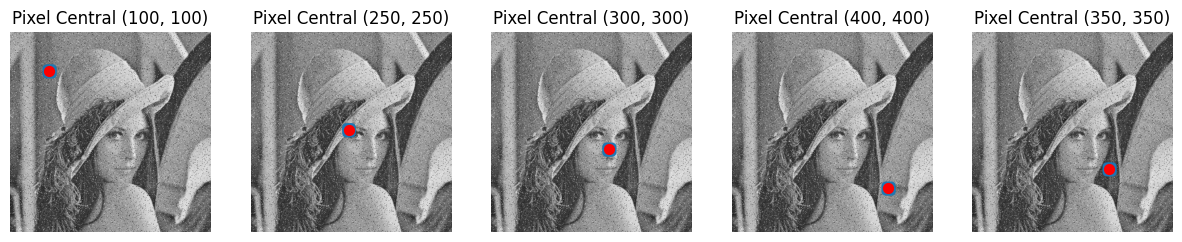

In [8]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21):
    half = patch_size // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            for di, dj in [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]:
                ni, nj = i + di, j + dj
                if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                    weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                    G.add_edge((i, j), (ni, nj), weight=weight)
    return G

def visualize_graph_with_paths(image, centers, patch_size):
    fig, axes = plt.subplots(1, len(centers), figsize=(15, 5))
    
    for ax, center in zip(axes, centers):
        G = build_graph(image, center, patch_size)
        pos = {node: (node[1], node[0]) for node in G.nodes()}
        
        # Calcular caminhos geodésicos do centro para todos os outros nós
        shortest_paths = nx.single_source_dijkstra_path(G, center)
        
        ax.imshow(image, cmap='gray')
        nx.draw(G, pos, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[center], node_color='red', node_size=50, ax=ax)
        
        for target in shortest_paths.keys():
            path_edges = list(zip(shortest_paths[target], shortest_paths[target][1:]))
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='blue', width=1, ax=ax)
        
        ax.set_title(f"Pixel Central {center}")
    
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Definir pixels centrais para visualização dos grafos
centers = [(100, 100), (250, 250), (300, 300), (400, 400), (350, 350)]
visualize_graph_with_paths(image, centers, patch_size=21)

In [ ]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21):
    half = patch_size // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            for di, dj in [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]:
                ni, nj = i + di, j + dj
                if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                    weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                    G.add_edge((i, j), (ni, nj), weight=weight)
    return G

def visualize_graph_with_paths(image, centers, patch_size):
    fig, axes = plt.subplots(1, len(centers), figsize=(20, 5))
    
    for ax, center in zip(axes, centers):
        G = build_graph(image, center, patch_size)
        pos = {node: (node[1], node[0]) for node in G.nodes()}
        
        # Calcular caminhos geodésicos do centro para todos os outros nós
        shortest_paths = nx.single_source_dijkstra_path(G, center)
        
        ax.imshow(image, cmap='gray')
        nx.draw(G, pos, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[center], node_color='red', node_size=50, ax=ax)
        
        for target in shortest_paths.keys():
            path_edges = list(zip(shortest_paths[target], shortest_paths[target][1:]))
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='blue', width=1, ax=ax)
        
        ax.set_title(f"Pixel Central {center}")
    
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Definir pixels centrais para visualização dos grafos
centers = [(100, 100), (250, 250), (300, 300), (400, 400), (350, 350)]
visualize_graph_with_paths(image, centers, patch_size=21)


In [ ]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21):
    half = patch_size // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            for di, dj in [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]:
                ni, nj = i + di, j + dj
                if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                    weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                    G.add_edge((i, j), (ni, nj), weight=weight)
    return G

def visualize_graph_with_paths(image, centers, patch_size):
    fig, axes = plt.subplots(1, len(centers), figsize=(20, 5))
    
    for ax, center in zip(axes, centers):
        G = build_graph(image, center, patch_size)
        pos = {node: (node[1], node[0]) for node in G.nodes()}
        
        # Calcular caminhos geodésicos do centro para todos os outros nós
        shortest_paths = nx.single_source_dijkstra_path(G, center)
        
        ax.imshow(image, cmap='gray')
        nx.draw(G, pos, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[center], node_color='red', node_size=50, ax=ax)
        
        for target in shortest_paths.keys():
            path_edges = list(zip(shortest_paths[target], shortest_paths[target][1:]))
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='blue', width=1, ax=ax)
        
        ax.set_title(f"Pixel Central {center}")
    
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Definir pixels centrais para visualização dos grafos
centers = [(100, 100), (250, 250), (300, 0), (400, 400), (350, 350)]
visualize_graph_with_paths(image, centers, patch_size=21)


In [ ]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21):
    half = patch_size // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            for di, dj in [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]:
                ni, nj = i + di, j + dj
                if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                    weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                    G.add_edge((i, j), (ni, nj), weight=weight)
    return G

def visualize_graphs(centers, image, patch_size):
    fig, axes = plt.subplots(1, len(centers), figsize=(20, 5))
    
    for ax, center in zip(axes, centers):
        G = build_graph(image, center, patch_size)
        pos = {node: (node[1], node[0]) for node in G.nodes()}
        
        # Calcular caminhos geodésicos do centro para todos os outros nós
        shortest_paths = nx.single_source_dijkstra_path(G, center)
        
        ax.set_title(f"Grafo - Pixel Central {center}")
        nx.draw(G, pos, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[center], node_color='red', node_size=50, ax=ax)
        
        for target in shortest_paths.keys():
            path_edges = list(zip(shortest_paths[target], shortest_paths[target][1:]))
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='blue', width=1, ax=ax)
        
        ax.axis("off")  # Remover eixos
    
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Definir os pixels centrais
centers = [(100, 100), (250, 250), (300, 300), (400, 400), (350, 350)]
visualize_graphs(centers, image, patch_size=21)


C:\Users\adria\AppData\Local\Temp\ipykernel_7440\663087555.py:26: RuntimeWarning: overflow encountered in scalar subtract
  if abs(image[i, j] - image[x0, y0]) < 30:  # Critério de similaridade arbitrário


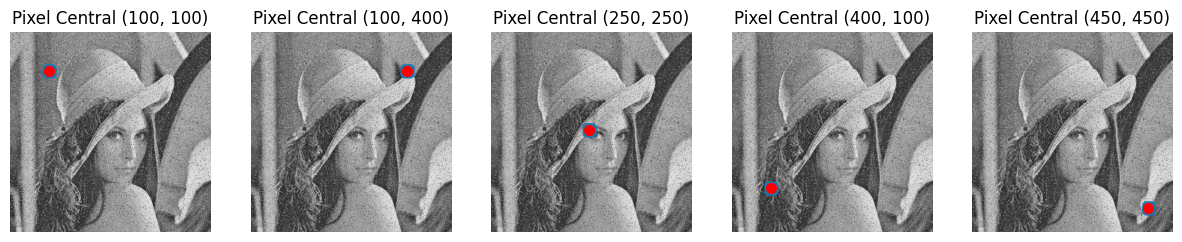

In [21]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21, similarity_patch=5):
    half = patch_size // 2
    half_similarity = similarity_patch // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            # Conectar apenas pixels similares ao central dentro do patch de similaridade
            if abs(image[i, j] - image[x0, y0]) < 30:  # Critério de similaridade arbitrário
                for di in range(-half_similarity, half_similarity + 1):
                    for dj in range(-half_similarity, half_similarity + 1):
                        ni, nj = i + di, j + dj
                        if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                            weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                            G.add_edge((i, j), (ni, nj), weight=weight)
    return G

def visualize_graph_with_paths(image, centers, patch_size, similarity_patch):
    fig, axes = plt.subplots(1, len(centers), figsize=(15, 5))
    
    for ax, center in zip(axes, centers):
        G = build_graph(image, center, patch_size, similarity_patch)
        pos = {node: (node[1], node[0]) for node in G.nodes()}
        
        # Calcular caminhos geodésicos do centro apenas para pixels similares
        shortest_paths = nx.single_source_dijkstra_path(G, center)
        
        ax.imshow(image, cmap='gray')
        nx.draw(G, pos, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[center], node_color='red', node_size=50, ax=ax)
        
        for target in shortest_paths.keys():
            path_edges = list(zip(shortest_paths[target], shortest_paths[target][1:]))
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='blue', width=1, ax=ax)
        
        ax.set_title(f"Pixel Central {center}")
    
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Definir pixels centrais para visualização dos grafos
centers = [(100, 100), (100, 400), (250, 250), (400, 100), (450, 450)]
visualize_graph_with_paths(image, centers, patch_size=21, similarity_patch=5)

In [ ]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21, similarity_patch=5):
    half = patch_size // 2
    half_similarity = similarity_patch // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            # Conectar apenas pixels similares ao central dentro do patch de similaridade
            if abs(image[i, j] - image[x0, y0]) < 30:  # Critério de similaridade arbitrário
                for di in range(-half_similarity, half_similarity + 1):
                    for dj in range(-half_similarity, half_similarity + 1):
                        ni, nj = i + di, j + dj
                        if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                            weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                            G.add_edge((i, j), (ni, nj), weight=weight)
    return G

def visualize_graphs(centers, patch_size, similarity_patch):
    fig, axes = plt.subplots(1, len(centers), figsize=(15, 5))
    
    for ax, center in zip(axes, centers):
        G = build_graph(image, center, patch_size, similarity_patch)
        pos = {node: (node[1], node[0]) for node in G.nodes()}
        
        # Calcular caminhos geodésicos do centro apenas para pixels similares
        shortest_paths = nx.single_source_dijkstra_path(G, center)
        
        nx.draw(G, pos, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[center], node_color='red', node_size=50, ax=ax)
        
        for target in shortest_paths.keys():
            path_edges = list(zip(shortest_paths[target], shortest_paths[target][1:]))
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='blue', width=1, ax=ax)
        
        ax.set_title(f"Pixel Central {center}")
    
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Definir pixels centrais para visualização dos grafos
centers = [(100, 100), (250, 250), (300, 300), (400, 400), (350, 350)]
visualize_graphs(centers, patch_size=21, similarity_patch=5)


In [ ]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21, similarity_patch=5):
    half = patch_size // 2
    half_similarity = similarity_patch // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            # Conectar apenas pixels similares ao central dentro do patch de similaridade
            if abs(image[i, j] - image[x0, y0]) < 30:  # Critério de similaridade arbitrário
                for di in range(-half_similarity, half_similarity + 1):
                    for dj in range(-half_similarity, half_similarity + 1):
                        ni, nj = i + di, j + dj
                        if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                            weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                            G.add_edge((i, j), (ni, nj), weight=weight)
    return G

def visualize_graphs(centers, patch_size, similarity_patch):
    fig, axes = plt.subplots(1, len(centers), figsize=(15, 5))
    
    for ax, center in zip(axes, centers):
        G = build_graph(image, center, patch_size, similarity_patch)
        pos = {node: (node[1], node[0]) for node in G.nodes()}
        
        # Calcular caminhos geodésicos do centro apenas para pixels similares
        shortest_paths = nx.single_source_dijkstra_path(G, center)
        
        nx.draw(G, pos, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=[center], node_color='red', node_size=50, ax=ax)
        
        for target in shortest_paths.keys():
            path_edges = list(zip(shortest_paths[target], shortest_paths[target][1:]))
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='blue', width=1, ax=ax)
        
        ax.set_title(f"Pixel Central {center}")
    
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Definir pixels centrais para visualização dos grafos
centers = [(100, 100), (100, 400), (250, 250), (400, 100), (450, 450)]
visualize_graphs(centers, patch_size=21, similarity_patch=5)

In [ ]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21, similarity_patch=5, euclidean=False):
    half = patch_size // 2
    half_similarity = similarity_patch // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            # Conectar apenas pixels similares ao central dentro do patch de similaridade
            if abs(image[i, j] - image[x0, y0]) < 30:  # Critério de similaridade arbitrário
                for di in range(-half_similarity, half_similarity + 1):
                    for dj in range(-half_similarity, half_similarity + 1):
                        ni, nj = i + di, j + dj
                        if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                            weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                            if euclidean:
                                G.add_edge((x0, y0), (ni, nj), weight=weight)  # Ligação direta ao pixel central
                            else:
                                G.add_edge((i, j), (ni, nj), weight=weight)  # Caminho geodésico
    return G

def visualize_graphs(centers, patch_size, similarity_patch):
    fig, axes = plt.subplots(len(centers), 2, figsize=(10, 5 * len(centers)))
    
    for idx, center in enumerate(centers):
        G_geo = build_graph(image, center, patch_size, similarity_patch, euclidean=False)
        G_euc = build_graph(image, center, patch_size, similarity_patch, euclidean=True)
        
        pos_geo = {node: (node[1], node[0]) for node in G_geo.nodes()}
        pos_euc = {node: (node[1], node[0]) for node in G_euc.nodes()}
        
        # Calcular caminhos geodésicos do centro apenas para pixels similares
        shortest_paths = nx.single_source_dijkstra_path(G_geo, center)
        
        ax_geo, ax_euc = axes[idx]
        nx.draw(G_geo, pos_geo, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax_geo)
        nx.draw_networkx_nodes(G_geo, pos_geo, nodelist=[center], node_color='red', node_size=50, ax=ax_geo)
        for target in shortest_paths.keys():
            path_edges = list(zip(shortest_paths[target], shortest_paths[target][1:]))
            nx.draw_networkx_edges(G_geo, pos_geo, edgelist=path_edges, edge_color='blue', width=1, ax=ax_geo)
        ax_geo.set_title(f"Geodésico {center}")
        
        nx.draw(G_euc, pos_euc, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax_euc)
        nx.draw_networkx_nodes(G_euc, pos_euc, nodelist=[center], node_color='red', node_size=50, ax=ax_euc)
        ax_euc.set_title(f"Euclidiano {center}")
    
    plt.tight_layout()
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Definir pixels centrais para visualização dos grafos
centers = [(100, 100), (250, 250), (300, 300), (400, 400), (350, 350)]
visualize_graphs(centers, patch_size=21, similarity_patch=5)

In [ ]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21, similarity_patch=5, euclidean=False):
    half = patch_size // 2
    half_similarity = similarity_patch // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            # Conectar apenas pixels similares ao central dentro do patch de similaridade
            if abs(image[i, j] - image[x0, y0]) < 30:  # Critério de similaridade arbitrário
                for di in range(-half_similarity, half_similarity + 1):
                    for dj in range(-half_similarity, half_similarity + 1):
                        ni, nj = i + di, j + dj
                        if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                            weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                            if euclidean:
                                G.add_edge((x0, y0), (ni, nj), weight=weight)  # Ligação direta ao pixel central
                            else:
                                G.add_edge((i, j), (ni, nj), weight=weight)  # Caminho geodésico
    return G

def visualize_graphs(centers, patch_size, similarity_patch):
    fig, axes = plt.subplots(len(centers), 3, figsize=(15, 5 * len(centers)))
    
    for idx, center in enumerate(centers):
        G_geo = build_graph(image, center, patch_size, similarity_patch, euclidean=False)
        G_euc = build_graph(image, center, patch_size, similarity_patch, euclidean=True)
        
        pos_geo = {node: (node[1], node[0]) for node in G_geo.nodes()}
        pos_euc = {node: (node[1], node[0]) for node in G_euc.nodes()}
        
        # Calcular caminhos geodésicos do centro apenas para pixels similares
        shortest_paths = nx.single_source_dijkstra_path(G_geo, center)
        
        ax_geo, ax_euc, ax_patch = axes[idx]
        nx.draw(G_geo, pos_geo, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax_geo)
        nx.draw_networkx_nodes(G_geo, pos_geo, nodelist=[center], node_color='red', node_size=50, ax=ax_geo)
        for target in shortest_paths.keys():
            path_edges = list(zip(shortest_paths[target], shortest_paths[target][1:]))
            nx.draw_networkx_edges(G_geo, pos_geo, edgelist=path_edges, edge_color='blue', width=1, ax=ax_geo)
        ax_geo.set_title(f"Geodésico {center}")
        
        nx.draw(G_euc, pos_euc, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax_euc)
        nx.draw_networkx_nodes(G_euc, pos_euc, nodelist=[center], node_color='red', node_size=50, ax=ax_euc)
        ax_euc.set_title(f"Euclidiano {center}")
        
        # Exibir a fatia da imagem
        half = patch_size // 2
        patch = image[center[0] - half:center[0] + half + 1, center[1] - half:center[1] + half + 1]
        ax_patch.imshow(patch, cmap='gray')
        ax_patch.set_title(f"Patch {center}")
        ax_patch.axis("off")
    
    plt.tight_layout()
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Definir pixels centrais para visualização dos grafos
centers = [(100, 100), (250, 250), (300, 300), (400, 400), (350, 350)]
visualize_graphs(centers, patch_size=21, similarity_patch=5)


C:\Users\adria\AppData\Local\Temp\ipykernel_7440\2444770903.py:26: RuntimeWarning: overflow encountered in scalar subtract
  if abs(image[i, j] - image[x0, y0]) < 30:  # Critério de similaridade arbitrário


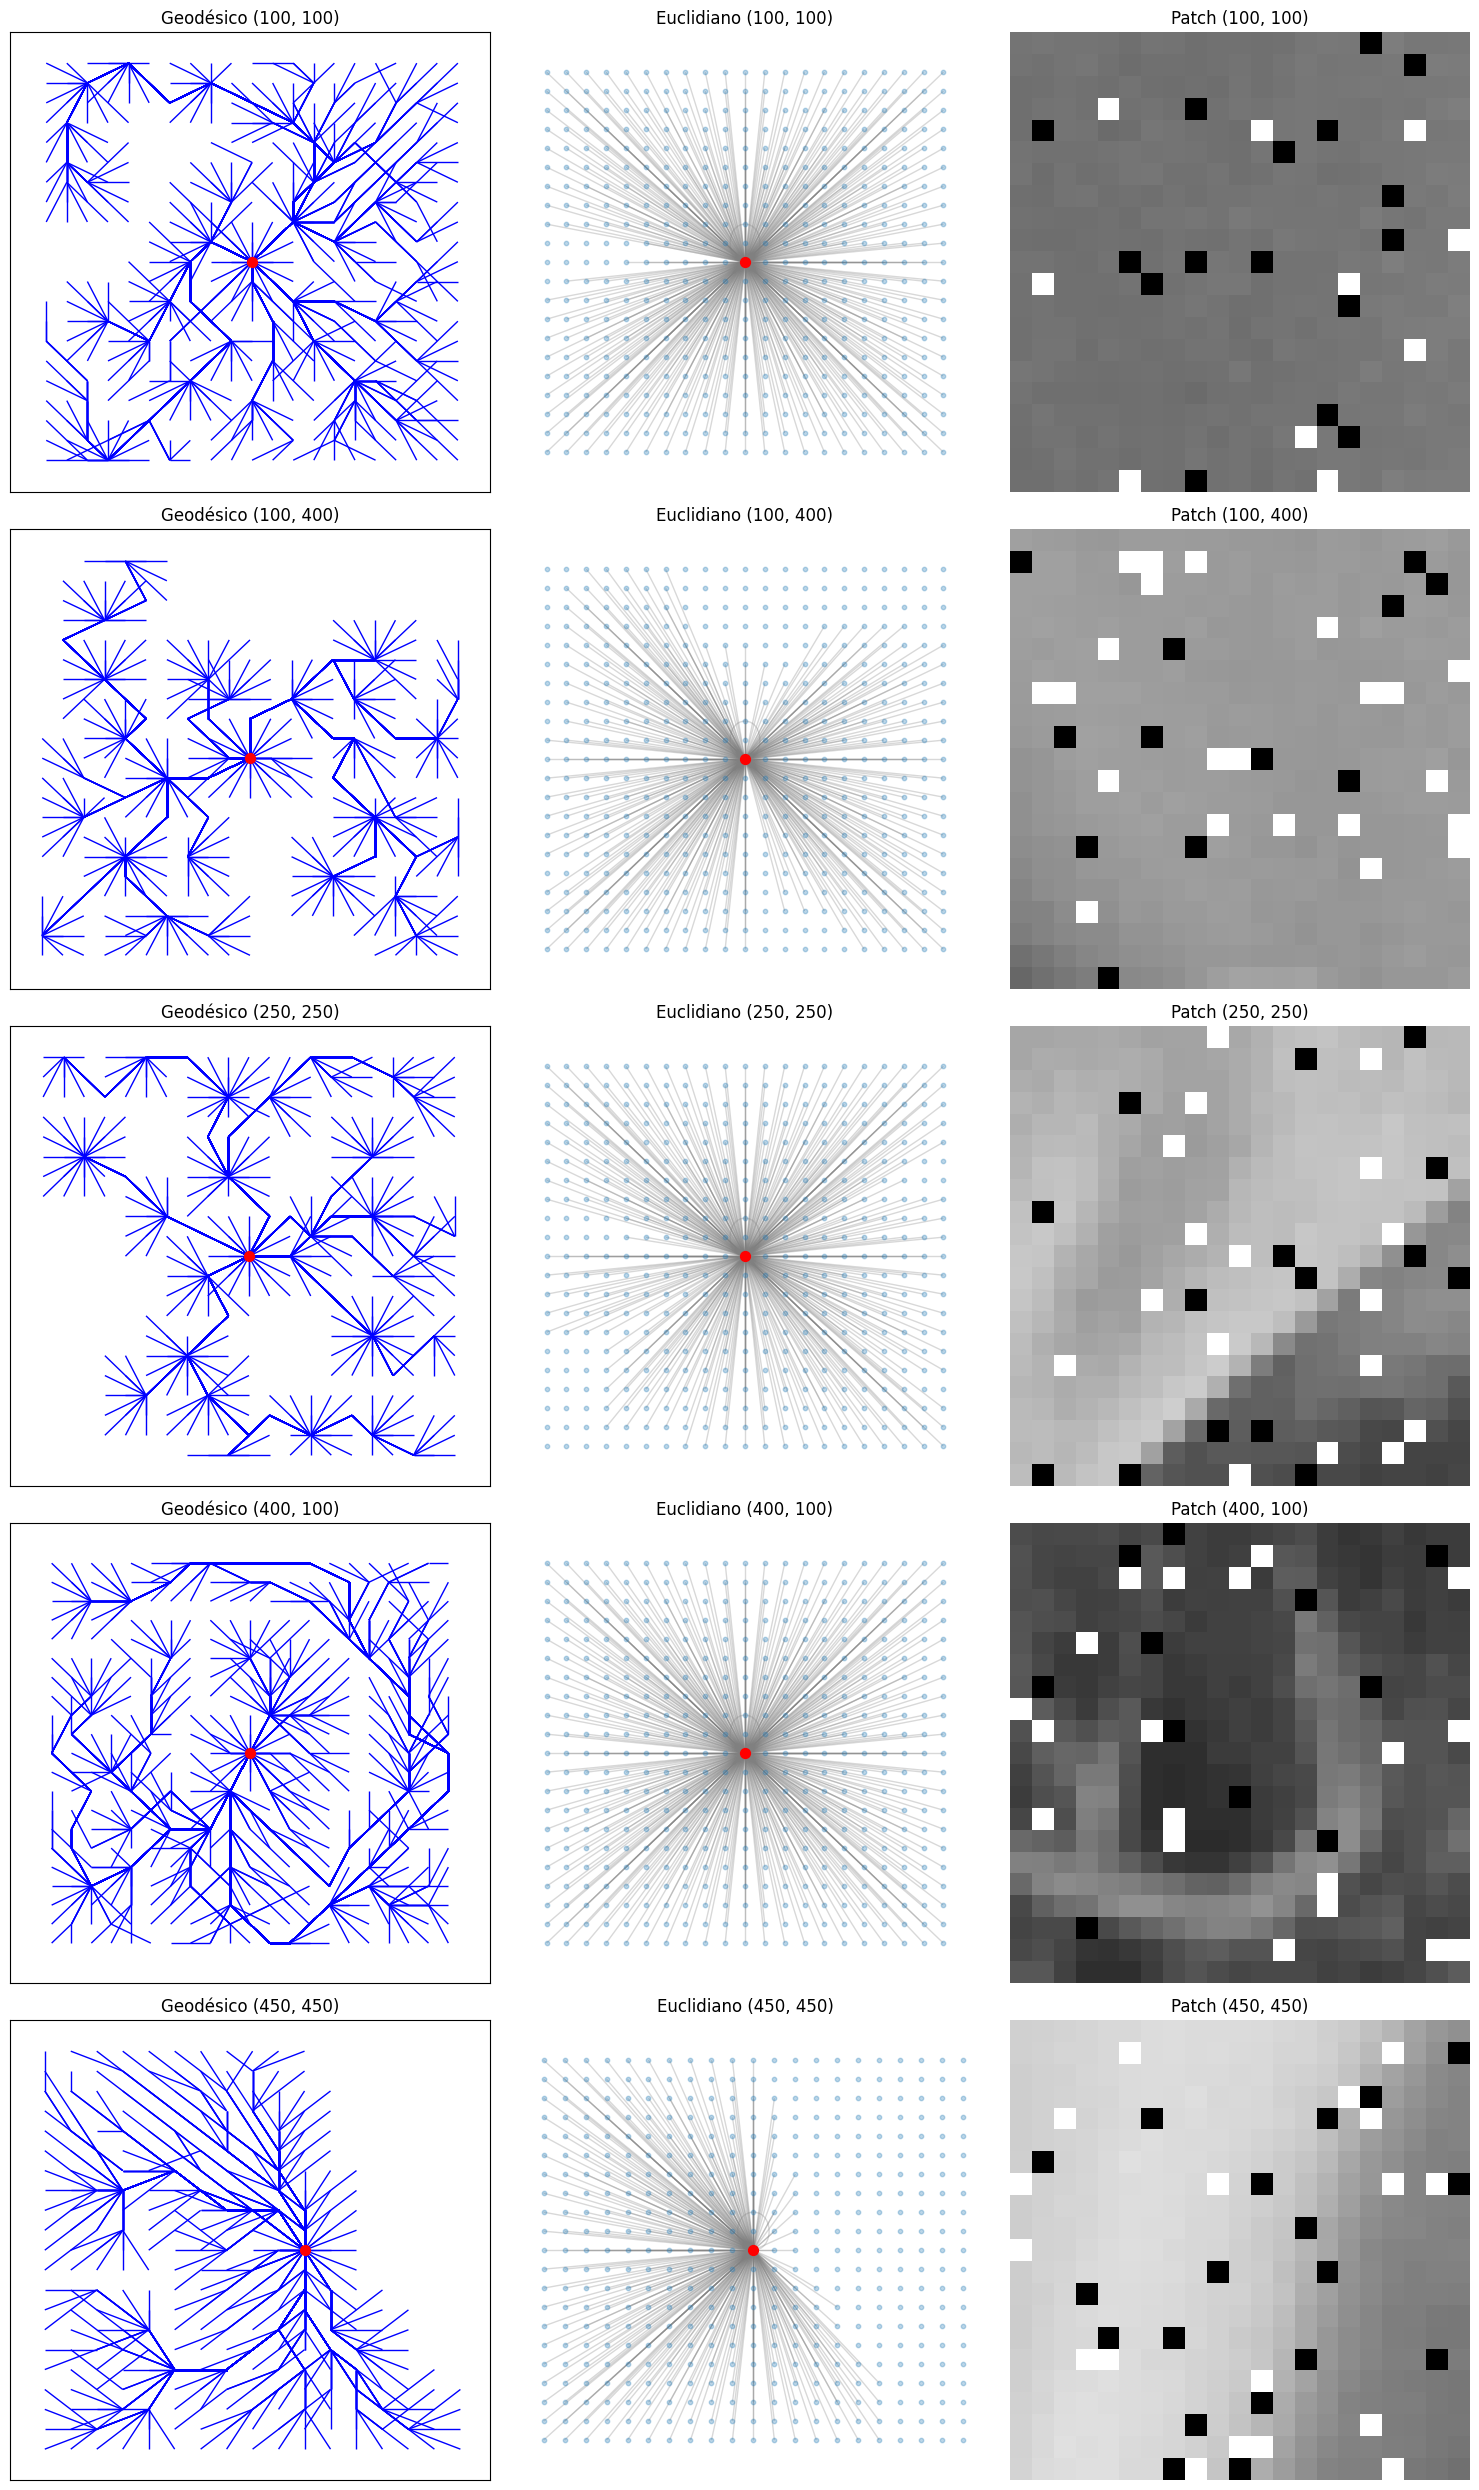

In [26]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

def load_image(path, add_noise=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if add_noise:
        img = random_noise(img, mode='s&p', amount=0.05)  # Adiciona ruído sal e pimenta
        img = (img * 255).astype(np.uint8)
    return img

def build_graph(image, center, patch_size=21, similarity_patch=5, euclidean=False):
    half = patch_size // 2
    half_similarity = similarity_patch // 2
    x0, y0 = center
    H, W = image.shape
    G = nx.Graph()
    
    for i in range(max(0, x0 - half), min(H, x0 + half + 1)):
        for j in range(max(0, y0 - half), min(W, y0 + half + 1)):
            G.add_node((i, j), intensity=image[i, j])
            
            # Conectar apenas pixels similares ao central dentro do patch de similaridade
            if abs(image[i, j] - image[x0, y0]) < 30:  # Critério de similaridade arbitrário
                for di in range(-half_similarity, half_similarity + 1):
                    for dj in range(-half_similarity, half_similarity + 1):
                        ni, nj = i + di, j + dj
                        if (max(0, x0 - half) <= ni < min(H, x0 + half + 1)) and (max(0, y0 - half) <= nj < min(W, y0 + half + 1)):
                            weight = np.abs(int(image[i, j]) - int(image[ni, nj])) + 1e-5
                            if euclidean:
                                G.add_edge((x0, y0), (ni, nj), weight=weight)  # Ligação direta ao pixel central
                            else:
                                G.add_edge((i, j), (ni, nj), weight=weight)  # Caminho geodésico
    return G

def visualize_graphs(centers, patch_size, similarity_patch):
    fig, axes = plt.subplots(len(centers), 3, figsize=(15, 5 * len(centers)))
    
    for idx, center in enumerate(centers):
        G_geo = build_graph(image, center, patch_size, similarity_patch, euclidean=False)
        G_euc = build_graph(image, center, patch_size, similarity_patch, euclidean=True)
        
        pos_geo = {node: (node[1], node[0]) for node in G_geo.nodes()}
        pos_euc = {node: (node[1], node[0]) for node in G_euc.nodes()}
        
        # Calcular caminhos geodésicos do centro apenas para pixels similares
        shortest_paths = nx.single_source_dijkstra_path(G_geo, center)
        
        ax_geo, ax_euc, ax_patch = axes[idx]
        nx.draw_networkx_nodes(G_geo, pos_geo, nodelist=[center], node_color='red', node_size=50, ax=ax_geo)
        for target in shortest_paths.keys():
            path_edges = list(zip(shortest_paths[target], shortest_paths[target][1:]))
            nx.draw_networkx_edges(G_geo, pos_geo, edgelist=path_edges, edge_color='blue', width=1, ax=ax_geo)
        ax_geo.set_title(f"Geodésico {center}")
        
        nx.draw(G_euc, pos_euc, node_size=10, edge_color='gray', alpha=0.3, with_labels=False, ax=ax_euc)
        nx.draw_networkx_nodes(G_euc, pos_euc, nodelist=[center], node_color='red', node_size=50, ax=ax_euc)
        ax_euc.set_title(f"Euclidiano {center}")
        
        # Exibir a fatia da imagem
        half = patch_size // 2
        patch = image[center[0] - half:center[0] + half + 1, center[1] - half:center[1] + half + 1]
        ax_patch.imshow(patch, cmap='gray')
        ax_patch.set_title(f"Patch {center}")
        ax_patch.axis("off")
    
    plt.tight_layout()
    plt.show()

# Carregar imagem
image_path = 'ruidosa/ruidosa_salt_pepper.png'
image = load_image(image_path)

# Definir pixels centrais para visualização dos grafos
centers = [(100, 100), (100, 400), (250, 250), (400, 100), (450, 450)]
visualize_graphs(centers, patch_size=21, similarity_patch=5)
